In [1]:
%reload_ext autoreload
%autoreload 2

In [24]:
from datetime import datetime, timedelta, timezone

import matplotlib.pyplot as plt
import narwhals as nw
import pandas as pd
import polars as pl

from backtester.backtester import MarketDataProvider
from backtester import samplers

In [3]:
plt.rcParams["figure.facecolor"] = "darkgray"
plt.rcParams["axes.facecolor"] = "lightgray"

In [4]:
t0 = datetime(2023, 1, 1, tzinfo=timezone.utc)
tf = datetime(2023, 2, 1, tzinfo=timezone.utc)
dt = timedelta(hours=1)

In [5]:
path_rate = samplers.get_path_rate()
paths_mark = samplers.get_paths_mark()
bars_spot = paths_mark.pipe(samplers.to_bars_spot, ["binc", "cbse"], ["usd", "usdt"])
bars_option = paths_mark.pipe(
    samplers.to_bars_option,
    "drbt",
    "btc",
    "usd",
    rules=samplers._MONTHLY,
    n_log_moneynesses=3,
)

In [6]:
path_rate.show()
paths_mark.show()
bars_spot.show()
bars_option.show()

time_start,time_end,rate
"datetime[μs, UTC]","datetime[μs, UTC]",f64
2025-01-01 00:00:00 UTC,2025-01-01 01:00:00 UTC,0.05
2025-01-01 01:00:00 UTC,2025-01-01 02:00:00 UTC,0.049711
2025-01-01 02:00:00 UTC,2025-01-01 03:00:00 UTC,0.049888
2025-01-01 03:00:00 UTC,2025-01-01 04:00:00 UTC,0.049972
2025-01-01 04:00:00 UTC,2025-01-01 05:00:00 UTC,0.049982


time_start,time_end,name,price
"datetime[μs, UTC]","datetime[μs, UTC]",str,f64
2025-01-01 00:00:00 UTC,2025-01-01 01:00:00 UTC,"""btc""",100729.480643
2025-01-01 01:00:00 UTC,2025-01-01 02:00:00 UTC,"""btc""",101076.294148
2025-01-01 02:00:00 UTC,2025-01-01 03:00:00 UTC,"""btc""",100642.497945
2025-01-01 03:00:00 UTC,2025-01-01 04:00:00 UTC,"""btc""",101299.334489
2025-01-01 04:00:00 UTC,2025-01-01 05:00:00 UTC,"""btc""",102057.024843


time_start,time_end,base,px_mark,exchange,quote,px_bid,px_ask
"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,str,str,f64,f64
2025-01-01 00:00:00 UTC,2025-01-01 01:00:00 UTC,"""btc""",100729.480643,"""binc""","""usd""",99722.185836,101736.775449
2025-01-01 01:00:00 UTC,2025-01-01 02:00:00 UTC,"""btc""",101076.294148,"""binc""","""usd""",100065.531206,102087.057089
2025-01-01 02:00:00 UTC,2025-01-01 03:00:00 UTC,"""btc""",100642.497945,"""binc""","""usd""",99636.072966,101648.922925
2025-01-01 03:00:00 UTC,2025-01-01 04:00:00 UTC,"""btc""",101299.334489,"""binc""","""usd""",100286.341144,102312.327834
2025-01-01 04:00:00 UTC,2025-01-01 05:00:00 UTC,"""btc""",102057.024843,"""binc""","""usd""",101036.454595,103077.595091


time_start,time_end,exchange,base,quote,strike,listing,expiry,kind,iv_bid,iv_ask,iv_mark
"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,f64,"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,f64,f64
2025-12-30 23:00:00 UTC,2025-12-31 00:00:00 UTC,"""drbt""","""btc""","""usd""",130000.0,2025-12-26 08:00:00 UTC,2026-01-30 08:00:00 UTC,"""c""",0.99,1.01,1.0
2025-12-30 22:00:00 UTC,2025-12-30 23:00:00 UTC,"""drbt""","""btc""","""usd""",130000.0,2025-12-26 08:00:00 UTC,2026-01-30 08:00:00 UTC,"""c""",0.99,1.01,1.0
2025-12-30 21:00:00 UTC,2025-12-30 22:00:00 UTC,"""drbt""","""btc""","""usd""",130000.0,2025-12-26 08:00:00 UTC,2026-01-30 08:00:00 UTC,"""c""",0.99,1.01,1.0
2025-12-30 20:00:00 UTC,2025-12-30 21:00:00 UTC,"""drbt""","""btc""","""usd""",130000.0,2025-12-26 08:00:00 UTC,2026-01-30 08:00:00 UTC,"""c""",0.99,1.01,1.0
2025-12-30 19:00:00 UTC,2025-12-30 20:00:00 UTC,"""drbt""","""btc""","""usd""",130000.0,2025-12-26 08:00:00 UTC,2026-01-30 08:00:00 UTC,"""c""",0.99,1.01,1.0


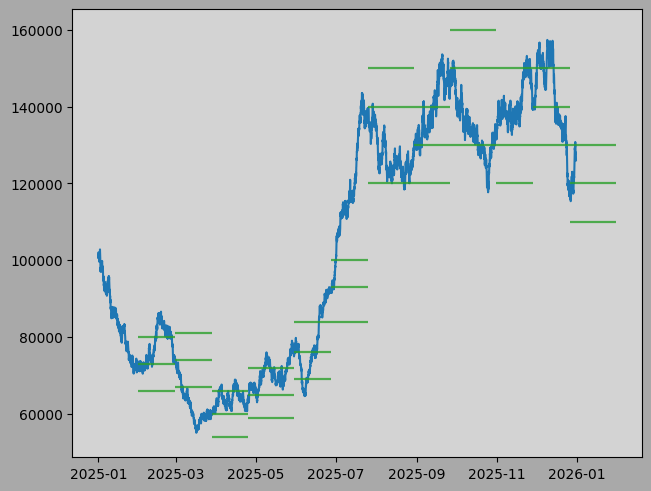

In [7]:
fig, ax = plt.subplots(layout="constrained")
ax.plot(
    paths_mark.filter(pl.col("name").eq("btc")).collect()["time_end"],
    paths_mark.filter(pl.col("name").eq("btc")).collect()["price"],
)
for k, tl, te in bars_option.select(["strike", "listing", "expiry"]).unique().collect().iter_rows():  # fmt: off
    dw = abs((te - tl) - timedelta(days=7))
    dm = abs((te - tl) - timedelta(days=30))
    dq = abs((te - tl) - timedelta(days=90))

    alphas = {dw: 1.0, dm: 0.8, dq: 0.2}
    colors = {dw: "tab:orange", dm: "tab:green", dq: "tab:red"}
    widths = {dw: 0.8, dm: 1.6, dq: 3.2}

    a = alphas[min(alphas.keys())]
    c = colors[min(colors.keys())]
    w = widths[min(widths.keys())]

    ax.hlines(k, tl, te, alpha=a, color=c, linewidth=w)

In [19]:
mdp = MarketDataProvider(path_rate, bars_spot, bars_option)
mdp

# NOTE: this is very slow. fix it
# mdp._get_lf_priced().collect()

In [21]:
mdp.lf_option.to_native().show()

time_start,time_end,exchange,base,quote,strike,listing,expiry,kind,iv_bid,iv_ask,iv_mark
"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,f64,"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,f64,f64
2025-12-30 23:00:00 UTC,2025-12-31 00:00:00 UTC,"""drbt""","""btc""","""usd""",130000.0,2025-12-26 08:00:00 UTC,2026-01-30 08:00:00 UTC,"""c""",0.99,1.01,1.0
2025-12-30 22:00:00 UTC,2025-12-30 23:00:00 UTC,"""drbt""","""btc""","""usd""",130000.0,2025-12-26 08:00:00 UTC,2026-01-30 08:00:00 UTC,"""c""",0.99,1.01,1.0
2025-12-30 21:00:00 UTC,2025-12-30 22:00:00 UTC,"""drbt""","""btc""","""usd""",130000.0,2025-12-26 08:00:00 UTC,2026-01-30 08:00:00 UTC,"""c""",0.99,1.01,1.0
2025-12-30 20:00:00 UTC,2025-12-30 21:00:00 UTC,"""drbt""","""btc""","""usd""",130000.0,2025-12-26 08:00:00 UTC,2026-01-30 08:00:00 UTC,"""c""",0.99,1.01,1.0
2025-12-30 19:00:00 UTC,2025-12-30 20:00:00 UTC,"""drbt""","""btc""","""usd""",130000.0,2025-12-26 08:00:00 UTC,2026-01-30 08:00:00 UTC,"""c""",0.99,1.01,1.0


In [23]:
mdp._get_lf_priced().to_native().show()

time_start,time_end,exchange,base,quote,strike,listing,expiry,is_call,spot,rate,iv_bid,iv_ask,iv_mark,px_bid,px_ask,px_mark,delta,gamma,vega,theta,rho
"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,f64,"datetime[μs, UTC]","datetime[μs, UTC]",bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-03-24 13:00:00 UTC,2025-03-24 14:00:00 UTC,"""drbt""","""btc""","""usd""",81000.0,2025-02-28 08:00:00 UTC,2025-03-28 08:00:00 UTC,true,60520.662118,0.05424,0.99,1.01,1.0,3.811842,4.732152,4.25306,0.002406,0.000001,46.015496,-2245.479989,1.452242
2025-03-28 04:00:00 UTC,2025-03-28 05:00:00 UTC,"""drbt""","""btc""","""usd""",81000.0,2025-02-28 08:00:00 UTC,2025-03-28 08:00:00 UTC,true,59957.23676,0.054138,0.99,1.01,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-28 07:00:00 UTC,2025-03-28 08:00:00 UTC,"""drbt""","""btc""","""usd""",81000.0,2025-02-28 08:00:00 UTC,2025-03-28 08:00:00 UTC,true,59876.35953,0.054386,0.99,1.01,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-03 19:00:00 UTC,2025-03-03 20:00:00 UTC,"""drbt""","""btc""","""usd""",81000.0,2025-02-28 08:00:00 UTC,2025-03-28 08:00:00 UTC,false,70402.269007,0.054173,0.99,1.01,1.0,13921.993224,14056.461759,13989.139697,-0.654558,0.00002,6723.426721,-46829.089301,-4032.196635
2025-03-08 22:00:00 UTC,2025-03-08 23:00:00 UTC,"""drbt""","""btc""","""usd""",81000.0,2025-02-28 08:00:00 UTC,2025-03-28 08:00:00 UTC,false,64419.253455,0.054197,0.99,1.01,1.0,17735.338291,17816.697711,17775.824689,-0.806869,0.000018,4067.970969,-34538.500698,-3702.680395


In [29]:
(pd.to_datetime("2025-03-28 08:00:00 UTC") - pd.to_datetime("2025-03-28 05:00:00 UTC")) / pd.to_timedelta("365 days")  # fmt: off

0.00034246575342465754

In [9]:
# # TODO: implement MarketDataProvider._get_lf_priced(...)
# mdp.get_target_option(
#     "drbt",
#     "btc",
#     "usd",
#     "c",
#     target_time=datetime(2025, 6, 1, tzinfo=timezone.utc),
#     target_delta=0.5,
#     target_tenor=timedelta(days=30),
# )

## Getting `lf_priced`

In [ ]:
# import narwhals as nw

# from backtester import schemas
# from utils import checks
# from utils import stats

In [ ]:
# # Get priced frame from option and spot.
# def _get_lf_priced(lf_option: pl.LazyFrame, lf_spot: pl.LazyFrame) -> pl.LazyFrame: ...


# lf_rate = nw.from_native(path_rate)
# lf_spot = nw.from_native(bars_spot)
# lf_option = nw.from_native(bars_option.with_columns(
#     pl.when(pl.col("kind").eq("c")).then(True).otherwise(False).alias("is_call")
# ).drop("kind"))  # fmt: off

In [ ]:
# def px_bs(
#     s: nw.Expr, k: nw.Expr, r: nw.Expr, sigma: nw.Expr, tau: nw.Expr, is_call: nw.Expr
# ) -> nw.Expr:
#     dp = ((s / k).log() + (r + sigma * sigma / 2) * tau) / (sigma * tau.sqrt())
#     dm = ((s / k).log() + (r - sigma * sigma / 2) * tau) / (sigma * tau.sqrt())
#     c = s * stats.norm_cdf(dp) - k * (0 - r * tau).exp() * stats.norm_cdf(dm)
#     p = k * (0 - r * tau).exp() * stats.norm_cdf(0 - dm) - s * stats.norm_cdf(0 - dp)
#     return nw.when(is_call).then(c).otherwise(p)

In [ ]:
# # Note that lf_option and lf_spot may contain multiple instruments.
# # We'll accept a mapping from option (exchange, base, quote) to spot (exchange, base quote),
# # to get a spot reference instrument for each option instrument.
# # For now just handle one item from the mapping.
# exchange_option, base_option, quote_option = "drbt", "btc", "usd"
# exchange_spot, base_spot, quote_spot = "cbse", "btc", "usd"

# lff_option = lf_option.filter([
#     nw.col("exchange") == exchange_option,
#     nw.col("base") == base_option,
#     nw.col("quote") == quote_option,
# ])  # fmt: off
# lff_spot = lf_spot.filter([
#     nw.col("exchange") == exchange_spot,
#     nw.col("base") == base_spot,
#     nw.col("quote") == quote_spot,
# ]).select(["time_start", "time_end", "px_mark"]).rename({"px_mark": "spot"})  # fmt: off

# s = nw.col("spot")
# k = nw.col("strike")
# r = nw.col("rate")
# v = nw.col("iv_mark")
# tau = (nw.col("expiry") - nw.col("time_end")).dt.total_seconds() / (365 * 24 * 3600)
# is_call = nw.col("is_call")

# ds: float = 0.01  # one cent
# dr: float = 0.0001  # one basis point
# dv: float = 0.01  # one ivol point
# dt: float = 1 / (365.25 * 24 * 60 * 60)  # one second

# keys = ["time_start", "time_end"] \
#      + ["exchange", "base", "quote", "strike", "listing", "expiry", "is_call"] \
#      + ["spot", "rate", "iv_bid", "iv_ask", "iv_mark"]  # fmt: off

# lff_priced = lff_option \
#     .join(lff_spot, ["time_start", "time_end"]) \
#     .join(lf_rate, ["time_start", "time_end"]) \
# .with_columns([
#     px_bs(s, k, r, nw.col("iv_bid"), tau, is_call).alias("px_bid"),
#     px_bs(s, k, r, nw.col("iv_ask"), tau, is_call).alias("px_ask"),
#     px_bs(s, k, r, nw.col("iv_mark"), tau, is_call).alias("px_mark"),
# ]).with_columns([
#     px_bs(s, k, r, v, tau, is_call).alias("_"),
#     px_bs((s + ds).clip(0), k, r, v, tau, is_call).alias("_s_up"),
#     px_bs((s - ds).clip(0), k, r, v, tau, is_call).alias("_s_dn"),
#     px_bs(s, k, r, (v + dv).clip(0), tau, is_call).alias("_v_up"),
#     px_bs(s, k, r, (v - dv).clip(0), tau, is_call).alias("_v_dn"),
#     px_bs(s, k, r, v, (tau + dt).clip(0), is_call).alias("_tau_up"),
#     px_bs(s, k, r, v, (tau - dt).clip(0), is_call).alias("_tau_dn"),
#     px_bs(s, k, (r + dr).clip(0), v, tau, is_call).alias("_r_up"),
#     px_bs(s, k, (r - dr).clip(0), v, tau, is_call).alias("_r_dn"),
# ]).with_columns([
#     ((nw.col("_s_up") - nw.col("_s_dn")) / (2 * ds)).alias("delta"),
#     ((nw.col("_s_up") - 2 * nw.col("_") + nw.col("_s_dn")) / (ds * ds)).alias("gamma"),
#     ((nw.col("_v_up") - nw.col("_v_dn")) / (2 * dv)).alias("vega"),
#     ((nw.col("_tau_dn") - nw.col("_tau_up")) / (2 * dt)).alias("theta"),
#     ((nw.col("_r_up") - nw.col("_r_dn")) / (2 * dr)).alias("rho"),
# ]).select([*keys,
#     *["px_bid", "px_ask", "px_mark"],
#     *["delta", "gamma", "vega", "theta", "rho"],
# ])  # fmt: off

# checks.check_schema(lff_priced, schemas.BARS_PRICED).to_native().show()

time_start,time_end,exchange,base,quote,strike,listing,expiry,is_call,spot,rate,iv_bid,iv_ask,iv_mark,px_bid,px_ask,px_mark,delta,gamma,vega,theta,rho
"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,f64,"datetime[μs, UTC]","datetime[μs, UTC]",bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-02-01 13:00:00 UTC,2025-02-01 14:00:00 UTC,"""drbt""","""btc""","""usd""",89000.0,2025-01-31 08:00:00 UTC,2025-02-28 08:00:00 UTC,true,74717.364816,0.05273,0.99,1.01,1.0,3438.705726,3581.377632,3509.905797,0.309767,0.000017,7133.595283,-49704.675459,1439.010949
2025-02-09 18:00:00 UTC,2025-02-09 19:00:00 UTC,"""drbt""","""btc""","""usd""",89000.0,2025-01-31 08:00:00 UTC,2025-02-28 08:00:00 UTC,true,72222.586007,0.054609,0.99,1.01,1.0,1710.926419,1805.101503,1757.820041,0.211342,0.000018,4708.754186,-47085.802682,686.083588
2025-02-19 21:00:00 UTC,2025-02-19 22:00:00 UTC,"""drbt""","""btc""","""usd""",89000.0,2025-01-31 08:00:00 UTC,2025-02-28 08:00:00 UTC,true,72520.225634,0.055609,0.99,1.01,1.0,488.860414,528.379449,508.443086,0.103094,0.000016,1975.951734,-43233.939968,160.67615
2025-02-20 00:00:00 UTC,2025-02-20 01:00:00 UTC,"""drbt""","""btc""","""usd""",89000.0,2025-01-31 08:00:00 UTC,2025-02-28 08:00:00 UTC,true,72790.740463,0.055675,0.99,1.01,1.0,501.803092,541.870788,521.661508,0.10562,0.000017,2003.384771,-44495.219882,162.801113
2025-02-23 13:00:00 UTC,2025-02-23 14:00:00 UTC,"""drbt""","""btc""","""usd""",89000.0,2025-01-31 08:00:00 UTC,2025-02-28 08:00:00 UTC,true,67850.099523,0.053905,0.99,1.01,1.0,24.09849,28.332441,26.155942,0.010298,0.000004,211.697547,-8167.898714,8.752616


## Normal CDF

In [ ]:
# import narwhals as nw
# import numpy as np

# from utils import stats

In [ ]:
# df = pl.DataFrame({"x": list(range(-100, 100))})
# lf = df.lazy()

In [ ]:
# approx_pl: pl.Series = (
#     nw.from_native(df)
#     .lazy()
#     .with_columns(nw.col("x").pipe(stats.norm_cdf).alias("cdf"))
#     .collect()
#     .to_native()["cdf"]
# )
# approx_np: np.ndarray = approx_pl.to_numpy().flatten()
# approx_np